In [1]:
import pandas as pd
import json

input_file = "terminal_assistant.parquet"
output_file = "terminal_assistant_cleaned.jsonl"

df = pd.read_parquet(input_file)

harmful_commands = [
    "rm -rf /",
    ":(){ :|:& };:",
    "mkfs",
    "shutdown",
    "reboot",
    "dd if=/dev/zero"
]

# Filter out harmful rows
# We check if any of the harmful strings exist within the 'completion' column
initial_count = len(df)
pattern = '|'.join(harmful_commands)
df_cleaned = df[~df['completion'].str.contains(pattern, case=False, na=False)].copy()

print(f"Removed {initial_count - len(df_cleaned)} harmful rows.")

# Convert to the ChatML format
def transform_to_messages(row):
    return {
        "messages": [
            {"role": "user", "content": row['prompt'].strip()},
            {"role": "assistant", "content": row['completion'].strip()}
        ]
    }

formatted_data = df_cleaned.apply(transform_to_messages, axis=1).tolist()

with open(output_file, 'w', encoding='utf-8') as f:
    for entry in formatted_data:
        json.dump(entry, f)
        f.write('\n')

print(f"Successfully saved {len(formatted_data)} clean examples to {output_file}")

/tmp/ipykernel_2754/4291227092.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_cleaned = df[~df['completion'].str.contains(pattern, case=False, na=False)].copy()


Removed 38 harmful rows.
Successfully saved 6115 clean examples to terminal_assistant_cleaned.jsonl


In [2]:
# Install compatible pyarrow first to avoid conflicts
!pip install pyarrow==21.0.0

# Then datasets
!pip install datasets

# Install a compatible version of transformers
!pip install transformers==5.2.0

# Core dependencies
!pip install git+https://github.com/huggingface/accelerate

# Unsloth
!pip install unsloth unsloth_zoo

# Other dependencies
!pip install huggingface_hub trl peft bitsandbytes


import torch
from IPython.display import Markdown, display

display(Markdown("## System Check"))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


from unsloth import FastLanguageModel

display(Markdown("## Loading Qwen3.5-0.8B with Unsloth"))

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = 2048,
    load_in_4bit = False,
    load_in_16bit = True,
)

print(" Model loaded successfully")


display(Markdown("##  Attaching LoRA Adapters"))
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    max_seq_length = 2048,
)

print(" LoRA adapters attached")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

from datasets import load_dataset
from IPython.display import Markdown, display

display(Markdown("## Loading  Dataset"))

dataset = load_dataset(
    "json",
    data_files={"train": "/content/terminal_assistant_cleaned.jsonl"},
    split="train"
)

print(f" Dataset loaded: {len(dataset)} records")
print("\n--- Sample record ---")
print(f"Prompt: {dataset[0]['messages'][0]['content']}")
print(f"Completion: {dataset[0]['messages'][1]['content']}")



def format_example(example):
    return {
        "text": (
            f"<|im_start|>user\n"
            f"{example['messages'][0]['content']}"
            f"<|im_end|>\n"
            f"<|im_start|>assistant\n"
            f"{example['messages'][1]['content']}"
            f"<|im_end|>"
        )
    }

dataset = dataset.map(format_example)


print("\n--- Formatted sample ---")
print(dataset[0]['text'])


from trl import SFTTrainer, SFTConfig

display(Markdown("## Starting Fine-tuning"))

trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    tokenizer = tokenizer,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = 2048,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        num_train_epochs = 3,
        logging_steps = 5,
        output_dir = "/content/outputs",
        optim = "adamw_8bit",
        seed = 3407,
        dataset_num_proc = 2,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
    ),
)

trainer_stats = trainer.train()
print(f"Training complete!")
print(f"Training time: {trainer_stats.metrics['train_runtime']:.0f} seconds")
print(f"Final loss: {trainer_stats.metrics['train_loss']:.4f}")


# display(Markdown("## Testing: Base Model vs Fine-tuned Model"))

# FastLanguageModel.for_inference(model)

# def ask(question):
#     messages = [{"role": "user", "content": question}]
#     inputs = tokenizer.apply_chat_template(
#         messages,
#         tokenize=True,
#         add_generation_prompt=True,
#         return_tensors="pt"
#     ).to("cuda")

#     outputs = model.generate(
#         input_ids=inputs,
#         max_new_tokens=512,
#         temperature=0.7,
#         top_p=0.8,
#         do_sample=True,
#     )
#     response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
#     return response



display(Markdown("##  Saving Fine-tuned Model"))


model.save_pretrained("/content/qwen35_lora")
tokenizer.save_pretrained("/content/qwen35_lora")


model.save_pretrained_merged(
    "/content/qwen35_merged",
    tokenizer,
    save_method="merged_16bit"
)

print(" Model saved!")
print("LoRA adapters: /content/qwen35_lora")
print("Merged model:  /content/qwen35_merged")


  Cloning https://github.com/huggingface/accelerate to /tmp/pip-req-build-g46fa0u1
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/accelerate /tmp/pip-req-build-g46fa0u1
  Resolved https://github.com/huggingface/accelerate to commit 16cb6eb80dd9aa8b4df1a63ef57863e455d53b83
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## System Check

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Loading Qwen3.5-0.8B with Unsloth

==((====))==  Unsloth 2026.8.18: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


...

Checking cache directory for required files...




Unsloth: Copying 1 files from cache to `/content/qwen35_merged`:   0%|          | 0/1 [00:00<?, ?it/s]

Unsloth: Copying 1 files from cache to `/content/qwen35_merged`: 100%|██████████| 1/1 [00:53<00:00, 53.31s/it]


Successfully copied all 1 files from cache to `/content/qwen35_merged`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.




Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 8905.10it/s]


Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:03<00:00, 123.23s/it]


Unsloth: Merge process complete. Saved to `/content/qwen35_merged`
 Model saved!
LoRA adapters: /content/qwen35_lora
Merged model:  /content/qwen35_merged


### Training Loss Graph

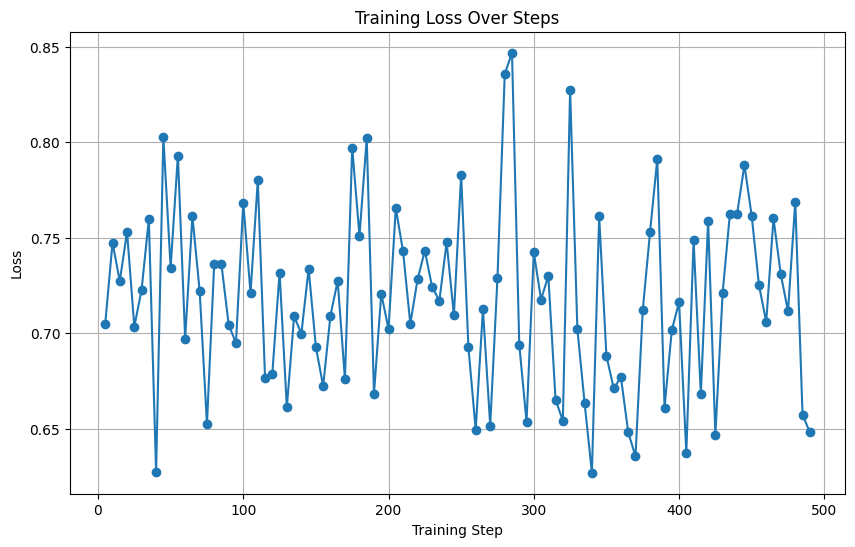

In [4]:
import matplotlib.pyplot as plt

losses = []
steps = []

for entry in trainer.state.log_history:
    if "loss" in entry and "step" in entry:
        losses.append(entry["loss"])
        steps.append(entry["step"])

if losses:
    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, marker="o")
    plt.title("Training Loss Over Steps")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("No training loss data found.")


In [7]:
# Load the merged model and tokenizer for inference
from unsloth import FastLanguageModel
from transformers import AutoTokenizer

merged_model_path = "/content/qwen35_merged"
model_inference, tokenizer_inference = FastLanguageModel.from_pretrained(
    model_name = merged_model_path,
    max_seq_length = 2048, # Must be the same as during training
    load_in_4bit = False,  # Or True, if you want 4bit inference
    load_in_16bit = True,  # Or False, if you want float32 inference
)

model_inference.eval()

print(" Merged model loaded successfully for inference.")

==((====))==  Unsloth 2026.8.18: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tokenizer you are loading from '/content/qwen35_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


 Merged model loaded successfully for inference.


In [8]:
import torch

# Define an ask function using the loaded merged model
def ask_merged(question):
    # Manually format the prompt based on Qwen's chat template
    # This format is derived from the format_example function used during training.
    formatted_prompt = (
        f"<|im_start|>user\n"
        f"{question}"
        f"<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    # Tokenize the manually formatted prompt string directly
    inputs = tokenizer_inference(
        formatted_prompt,
        return_tensors="pt"
    ).to("cuda") # Ensure input is on GPU if model is on GPU

    outputs = model_inference.generate(
        input_ids=inputs["input_ids"],
        max_new_tokens=512,
        temperature=0.7,
        top_p=0.8,
        do_sample=True,
    )
    response = tokenizer_inference.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response

print("`ask_merged` function defined.")

`ask_merged` function defined.


In [10]:
print(dataset[0]['messages'][0]['content'])
print(dataset[0]['messages'][1]['content'])

List all files in the current directory, including hidden ones, in long format.
ls -la


### Demonstration of the merged model

In [12]:
!pip install unsloth unsloth_zoo
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_path = "/content/qwen35_merged"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)

def ask_merged(query):
    messages = [
        {"role": "user", "content": query}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=64
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response

questions = [
    "List all files in the current directory",
    "Show the current working directory",
    "Create a new directory named backup",
    "Delete a file named temp.txt",
    "Rename file1.txt to file2.txt",
    "Copy all .log files to another directory",
    "Find all Python files in the home directory",
    "Display the contents of a file line by line",
    "Search for the word 'error' inside a log file",
    "Show all currently running processes"
]
for query in questions:
  print()
  print(ask_merged(query))
  print()

The tokenizer you are loading from '/content/qwen35_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


user
List all files in the current directory
assistant
<think>

</think>

ls -la


user
Show the current working directory
assistant
<think>

</think>

$ pwd


user
Create a new directory named backup
assistant
<think>

</think>

mkdir -p backup


user
Delete a file named temp.txt
assistant
<think>

</think>

rm temp.txt


user
Rename file1.txt to file2.txt
assistant
<think>

</think>

mv file1.txt file2.txt


user
Copy all .log files to another directory
assistant
<think>

</think>

cp *.log /path/to/destination/


user
Find all Python files in the home directory
assistant
<think>

</think>

find ~ -type f -name "*.py"


user
Display the contents of a file line by line
assistant
<think>

</think>

$ cat file.txt


user
Search for the word 'error' inside a log file
assistant
<think>

</think>

grep -i "error" /var/log/syslog


user
Show all currently running processes
assistant
<think>

</think>

ps aux



### Evaluation On custom data set 84 samples

In [13]:
eval_examples = [
    {"prompt": "List all files including hidden ones", "expected": ["ls -a", "ls -la", "ls -al"]},
    {"prompt": "Show disk usage of the current directory", "expected": ["du -sh .", "du -h ."]},
    {"prompt": "Find all files larger than 100MB", "expected": ["find . -size +100M"]},
    {"prompt": "Count the number of lines in a file", "expected": ["wc -l"]},
    {"prompt": "Compress a folder named data into a tar.gz archive", "expected": ["tar -czvf data.tar.gz data", "tar -czf data.tar.gz data"]},
    {"prompt": "Show the last 20 lines of a log file", "expected": ["tail -n 20", "tail -20"]},
    {"prompt": "Delete all .tmp files in the current directory", "expected": ["rm *.tmp", "find . -name '*.tmp' -delete"]},

    # File and directory operations
    {"prompt": "Create a directory named projects", "expected": ["mkdir projects"]},
    {"prompt": "Create a directory and all missing parent directories", "expected": ["mkdir -p projects/src"]},
    {"prompt": "Create an empty file named notes.txt", "expected": ["touch notes.txt"]},
    {"prompt": "Copy file.txt to backup.txt", "expected": ["cp file.txt backup.txt"]},
    {"prompt": "Copy a directory named src to backup", "expected": ["cp -r src backup"]},
    {"prompt": "Move old.txt into the archive directory", "expected": ["mv old.txt archive/"]},
    {"prompt": "Rename file old.txt to new.txt", "expected": ["mv old.txt new.txt"]},
    {"prompt": "Delete a file named test.txt", "expected": ["rm test.txt"]},
    {"prompt": "Delete a directory named temp and everything inside it", "expected": ["rm -rf temp"]},

    # Navigation
    {"prompt": "Show the current working directory", "expected": ["pwd"]},
    {"prompt": "Change to the home directory", "expected": ["cd ~", "cd $HOME"]},
    {"prompt": "Go to the parent directory", "expected": ["cd .."]},
    {"prompt": "Go back to the previous directory", "expected": ["cd -"]},

    # Searching
    {"prompt": "Find all files named config.txt", "expected": ["find . -name 'config.txt'", "find . -name config.txt"]},
    {"prompt": "Find all Python files recursively", "expected": ["find . -name '*.py'", "find . -type f -name '*.py'"]},
    {"prompt": "Find all empty files", "expected": ["find . -type f -empty"]},
    {"prompt": "Find directories named logs", "expected": ["find . -type d -name 'logs'"]},
    {"prompt": "Search for the word ERROR inside log.txt", "expected": ["grep 'ERROR' log.txt", "grep ERROR log.txt"]},
    {"prompt": "Search recursively for the word TODO", "expected": ["grep -r 'TODO' .", "grep -R 'TODO' ."]},
    {"prompt": "Search for ERROR ignoring case", "expected": ["grep -i 'ERROR' log.txt", "grep -i ERROR log.txt"]},

    # Text processing
    {"prompt": "Display the contents of a file", "expected": ["cat file.txt"]},
    {"prompt": "Display a file one screen at a time", "expected": ["less file.txt", "more file.txt"]},
    {"prompt": "Show the first 10 lines of a file", "expected": ["head file.txt", "head -n 10 file.txt"]},
    {"prompt": "Show the last 10 lines of a file", "expected": ["tail file.txt", "tail -n 10 file.txt"]},
    {"prompt": "Count lines, words, and characters in a file", "expected": ["wc file.txt"]},
    {"prompt": "Sort the lines of a file alphabetically", "expected": ["sort file.txt"]},
    {"prompt": "Remove duplicate adjacent lines", "expected": ["uniq file.txt"]},
    {"prompt": "Print only the first column of a space-separated file", "expected": ["awk '{print $1}' file.txt"]},

    # Permissions
    {"prompt": "Make script.sh executable", "expected": ["chmod +x script.sh"]},
    {"prompt": "Give the owner read, write, and execute permissions", "expected": ["chmod u+rwx script.sh"]},
    {"prompt": "Set permissions of file.txt to 644", "expected": ["chmod 644 file.txt"]},
    {"prompt": "Show the permissions of a file", "expected": ["ls -l file.txt"]},
    {"prompt": "Change the owner of file.txt to user alice", "expected": ["chown alice file.txt"]},

    # Processes
    {"prompt": "Show running processes", "expected": ["ps", "ps aux"]},
    {"prompt": "Show all running processes", "expected": ["ps aux", "ps -ef"]},
    {"prompt": "Find processes containing the word python", "expected": ["ps aux | grep python", "pgrep python"]},
    {"prompt": "Kill a process with PID 1234", "expected": ["kill 1234"]},
    {"prompt": "Force kill a process with PID 1234", "expected": ["kill -9 1234"]},
    {"prompt": "Show real-time system processes", "expected": ["top"]},

    # Networking
    {"prompt": "Test connectivity to google.com", "expected": ["ping google.com"]},
    {"prompt": "Show network interfaces", "expected": ["ip addr", "ifconfig"]},
    {"prompt": "Show the IP address of the machine", "expected": ["hostname -I", "ip addr"]},
    {"prompt": "Download a file from a URL using curl", "expected": ["curl -O URL", "curl -o file URL"]},
    {"prompt": "Download a file using wget", "expected": ["wget URL"]},

    # Archives
    {"prompt": "Extract a tar.gz archive", "expected": ["tar -xzvf archive.tar.gz", "tar -xzf archive.tar.gz"]},
    {"prompt": "Create a tar archive named backup.tar", "expected": ["tar -cvf backup.tar data", "tar -cf backup.tar data"]},
    {"prompt": "Extract a zip file", "expected": ["unzip archive.zip"]},
    {"prompt": "Create a zip archive of a folder", "expected": ["zip -r archive.zip folder"]},

    # Environment variables
    {"prompt": "Show all environment variables", "expected": ["env", "printenv"]},
    {"prompt": "Print the PATH environment variable", "expected": ["echo $PATH", "printenv PATH"]},
    {"prompt": "Set an environment variable named NAME to John", "expected": ["export NAME=John"]},
    {"prompt": "Show the value of the HOME variable", "expected": ["echo $HOME"]},

    # Pipes and redirection
    {"prompt": "Save the output of ls to files.txt", "expected": ["ls > files.txt"]},
    {"prompt": "Append the output of ls to files.txt", "expected": ["ls >> files.txt"]},
    {"prompt": "Redirect errors to error.log", "expected": ["2> error.log"]},
    {"prompt": "Pipe the output of ps to grep for python", "expected": ["ps aux | grep python"]},
    {"prompt": "Count the number of files in the current directory", "expected": ["ls | wc -l"]},

    # Variables and shell scripting
    {"prompt": "Print Hello World from the shell", "expected": ["echo 'Hello World'", "echo \"Hello World\""]},
    {"prompt": "Create a shell variable named count with value 10", "expected": ["count=10"]},
    {"prompt": "Run a command and print its exit status", "expected": ["echo $?", "echo $?"]},
    {"prompt": "Run script.sh using Bash", "expected": ["bash script.sh"]},
    {"prompt": "Run script.sh in the background", "expected": ["./script.sh &", "bash script.sh &"]},

    # Git
    {"prompt": "Show the current Git status", "expected": ["git status"]},
    {"prompt": "Show the commit history", "expected": ["git log"]},
    {"prompt": "Stage all modified files", "expected": ["git add .", "git add -A"]},
    {"prompt": "Commit staged changes with message 'update'", "expected": ["git commit -m 'update'", "git commit -m \"update\""]},
    {"prompt": "Show the differences between working files and the last commit", "expected": ["git diff"]},

    # System information
    {"prompt": "Show available memory", "expected": ["free -h"]},
    {"prompt": "Show disk space usage", "expected": ["df -h"]},
    {"prompt": "Show the Linux kernel version", "expected": ["uname -r"]},
    {"prompt": "Show detailed system information", "expected": ["uname -a"]},
    {"prompt": "Show the current date and time", "expected": ["date"]},

    # Command history and utilities
    {"prompt": "Show previously executed commands", "expected": ["history"]},
    {"prompt": "Clear the terminal screen", "expected": ["clear"]},
    {"prompt": "Find where the ls command is located", "expected": ["which ls", "command -v ls"]},
    {"prompt": "Show the manual page for grep", "expected": ["man grep"]},
    {"prompt": "Show the type of a command", "expected": ["type ls"]},
]

def evaluate_model(ask_fn, eval_examples):
    results = []
    correct = 0
    for ex in eval_examples:
        response = ask_fn(ex["prompt"]).strip()
        # crude check: does the response contain one of the acceptable substrings
        is_correct = any(exp.lower() in response.lower() for exp in ex["expected"])
        correct += is_correct
        results.append({
            "prompt": ex["prompt"],
            "expected": ex["expected"],
            "generated": response,
            "correct": is_correct,
        })
    accuracy = correct / len(eval_examples)
    print(f"Eval accuracy: {accuracy:.1%} ({correct}/{len(eval_examples)})")
    return results, accuracy

results, accuracy = evaluate_model(ask_merged, eval_examples)
print("accuracy" + str(accuracy))

Eval accuracy: 59.5% (50/84)
accuracy0.5952380952380952
